# Phase 1 — Exploratory data analysis: class balance

Heart disease target: **0** = no angiographic disease, **1** = disease present (binary label in `heart-disease.csv`).

Roadmap expectation: roughly **~165 positive / ~138 negative** — we verify that below, then visualize and record how we will **control** imbalance during training (not by changing labels in EDA).

In [7]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

sns.set_theme(style="whitegrid", context="notebook")


def resolve_data_path() -> Path:
    """Find data/heart-disease.csv whether the kernel cwd is repo root or notebook/."""
    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        candidate = base / "data" / "heart-disease.csv"
        if candidate.is_file():
            return candidate
    raise FileNotFoundError("Could not find data/heart-disease.csv above the current working directory.")


DATA_PATH = resolve_data_path()
df = pd.read_csv(DATA_PATH)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 1. Class distribution

Report raw counts and proportions for the binary target.

In [8]:
TARGET = "target"
LABEL_MAP = {0: "No disease (0)", 1: "Disease (1)"}

counts = df[TARGET].value_counts().sort_index()
props = df[TARGET].value_counts(normalize=True).sort_index()
summary = (
    pd.DataFrame({"count": counts, "proportion": props})
    .rename(index=LABEL_MAP)
)
summary["proportion_pct"] = (summary["proportion"] * 100).round(2)
summary

,count,proportion,proportion_pct
target,,,
No disease (0),138,0.455446,45.54
Disease (1),165,0.544554,54.46


In [9]:
n = len(df)
n_neg, n_pos = int(counts.get(0, 0)), int(counts.get(1, 0))
ratio = n_pos / n_neg if n_neg else float("nan")
print(f"Rows: {n}")
print(f"Majority:min ratio (positive:negative): {ratio:.3f}:1")
print(f"Imbalance (|p - 0.5|): {abs(props.get(1, 0.5) - 0.5):.3f}")

Rows: 303
Majority:min ratio (positive:negative): 1.196:1
Imbalance (|p - 0.5|): 0.045


## 2. Visualization

Bar chart of class frequencies (absolute counts).

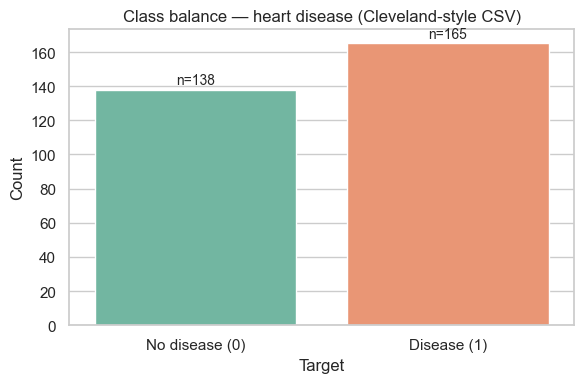

In [10]:
plot_df = (
    df[TARGET]
    .map(LABEL_MAP)
    .value_counts()
    .reindex([LABEL_MAP[0], LABEL_MAP[1]])
    .rename("count")
    .reset_index()
    .rename(columns={TARGET: "class"})
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=plot_df, x="class", y="count", hue="class", palette="Set2", dodge=False, ax=ax)
ax.set_xlabel("Target")
ax.set_ylabel("Count")
ax.set_title("Class balance — heart disease (Cleveland-style CSV)")
for i, row in plot_df.iterrows():
    ax.text(i, row["count"] + 3, f"n={int(row['count'])}", ha="center", fontsize=10)
plt.tight_layout()

## 3. Controlling imbalance (for later modeling)

EDA does **not** require resampling the dataframe. For **Phase 3** training we keep class proportions representative and apply one or more of:

- **`stratify=y`** in `train_test_split` / CV so every fold matches the global positive rate.
- **`class_weight='balanced'`** (or explicit weights) in models that support it — sklearn can derive weights inversely proportional to frequency.
- **Resampling** (e.g. SMOTE) only if we explicitly choose that pipeline; optional and not assumed here.

Below: stratified split check + `compute_class_weight` for reference weights.

In [11]:
y = df[TARGET]
X = df.drop(columns=[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

train_props = y_train.value_counts(normalize=True).sort_index()
test_props = y_test.value_counts(normalize=True).sort_index()
print("Global positive rate:", f"{props[1]:.4f}")
print("Train positive rate:  ", f"{train_props[1]:.4f}")
print("Test positive rate:   ", f"{test_props[1]:.4f}")

Global positive rate: 0.5446
Train positive rate:   0.5463
Test positive rate:    0.5395


In [12]:
classes = np.unique(y)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
weight_by_label = dict(zip(classes.tolist(), weights))
pd.Series(weight_by_label, name="balanced_weight").rename(LABEL_MAP)

No disease (0)    1.097826
Disease (1)       0.918182
Name: balanced_weight, dtype: float64